In [1]:
# ── Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────
BASE_DIR  = Path().resolve().parent
PROC_DIR  = BASE_DIR / 'data' / 'processed'
RAW_DIR   = BASE_DIR / 'data' / 'raw'
CHART_DIR = BASE_DIR / 'reports' / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi']     = 100

print('Setup complete. Chart output folder:', CHART_DIR)

Setup complete. Chart output folder: P:\bluestock_mf_capstone\reports\charts


In [2]:
# ── Load all cleaned datasets ─────────────────────────────────
nav    = pd.read_csv(PROC_DIR / 'clean_nav.csv',               parse_dates=['date'])
aum    = pd.read_csv(PROC_DIR / 'clean_aum.csv',               parse_dates=['date'])
sip    = pd.read_csv(PROC_DIR / 'clean_sip.csv',               parse_dates=['month'])
cat    = pd.read_csv(PROC_DIR / 'clean_category_inflows.csv',  parse_dates=['month'])
folio  = pd.read_csv(PROC_DIR / 'clean_folio_count.csv',       parse_dates=['month'])
txn    = pd.read_csv(PROC_DIR / 'clean_transactions.csv',      parse_dates=['transaction_date'])
port   = pd.read_csv(PROC_DIR / 'clean_portfolio_holdings.csv')
fund   = pd.read_csv(PROC_DIR / 'clean_fund_master.csv')
perf   = pd.read_csv(PROC_DIR / 'clean_performance.csv')

# Merge nav with fund names
nav_named = nav.merge(fund[['amfi_code','scheme_name','fund_house','sub_category']], on='amfi_code', how='left')

print('All datasets loaded successfully.')
print(f'NAV rows      : {len(nav):,}')
print(f'Transactions  : {len(txn):,}')
print(f'Portfolio rows: {len(port):,}')

All datasets loaded successfully.
NAV rows      : 64,320
Transactions  : 32,778
Portfolio rows: 322


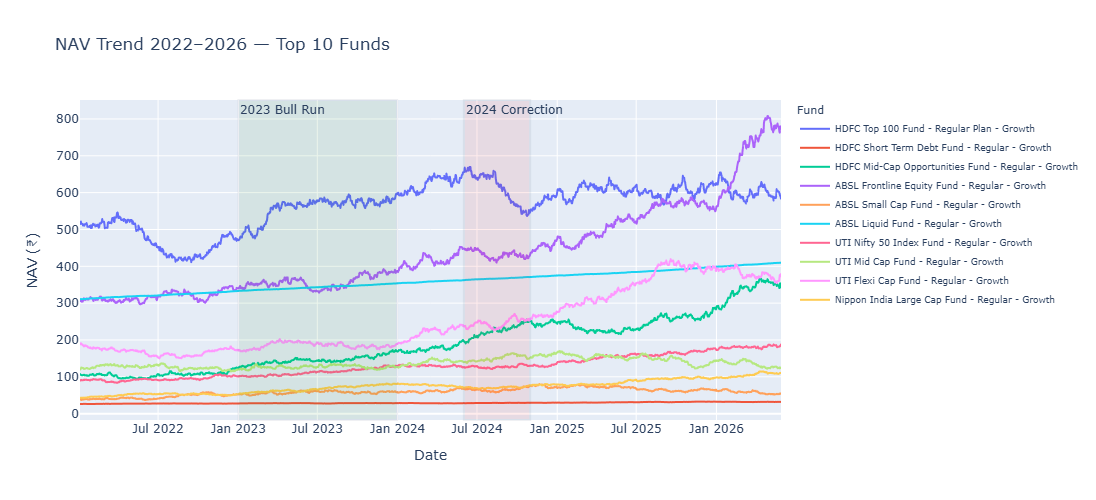

In [3]:
# Pick 10 representative funds for clarity
top10 = nav_named['amfi_code'].unique()[:10]
nav10 = nav_named[nav_named['amfi_code'].isin(top10)]

fig = px.line(
    nav10, x='date', y='nav', color='scheme_name',
    title='NAV Trend 2022–2026 — Top 10 Funds',
    labels={'nav': 'NAV (₹)', 'date': 'Date', 'scheme_name': 'Fund'}
)
# Highlight 2023 bull run
fig.add_vrect(x0='2023-01-01', x1='2023-12-31',
              fillcolor='green', opacity=0.07,
              annotation_text='2023 Bull Run', annotation_position='top left')
# Highlight 2024 correction
fig.add_vrect(x0='2024-06-01', x1='2024-10-31',
              fillcolor='red', opacity=0.07,
              annotation_text='2024 Correction', annotation_position='top left')
fig.update_layout(height=500, legend=dict(font=dict(size=9)))
try:
    fig.write_image(str(CHART_DIR / 'chart01_nav_trend.png'))
except Exception:
    pass  # kaleido not installed; skipping PNG export
fig.show()

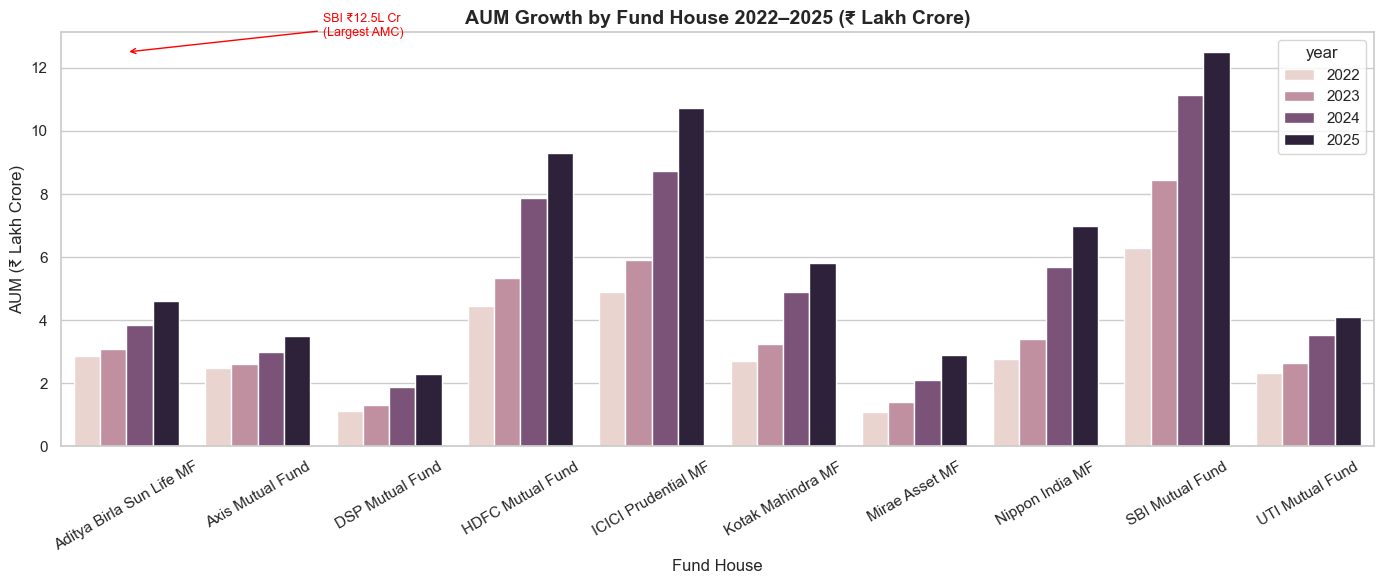

In [4]:
aum['year'] = aum['date'].dt.year
aum_yr = aum.groupby(['year','fund_house'])['aum_lakh_crore'].max().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=aum_yr, x='fund_house', y='aum_lakh_crore', hue='year', ax=ax)
ax.set_title('AUM Growth by Fund House 2022–2025 (₹ Lakh Crore)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fund House')
ax.set_ylabel('AUM (₹ Lakh Crore)')
ax.tick_params(axis='x', rotation=30)

# Annotate SBI max bar
sbi_max = aum_yr[aum_yr['fund_house']=='SBI Mutual Fund']['aum_lakh_crore'].max()
ax.annotate(f'SBI ₹{sbi_max}L Cr\n(Largest AMC)',
            xy=(0, sbi_max), xytext=(1.5, sbi_max + 0.5),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart02_aum_growth.png', dpi=150)
plt.show()

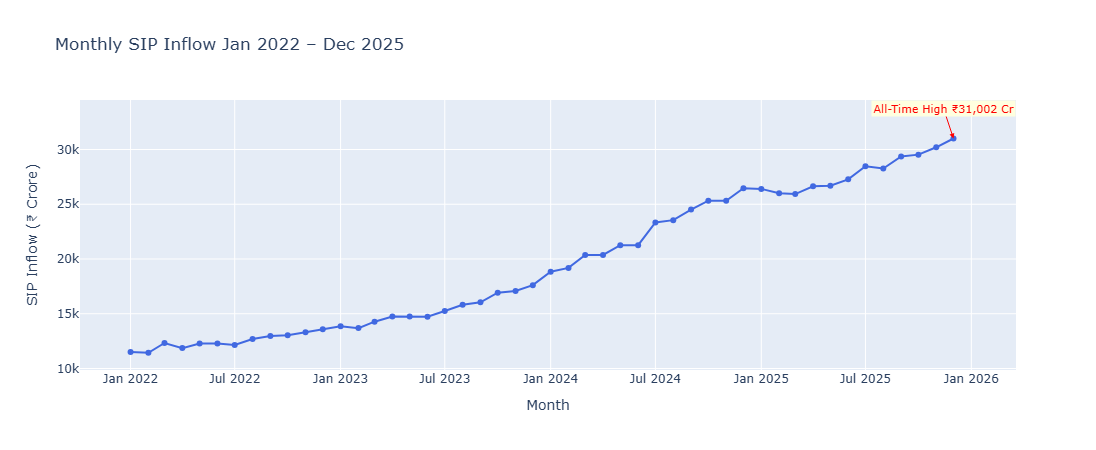

In [5]:
fig = px.line(
    sip, x='month', y='sip_inflow_crore',
    title='Monthly SIP Inflow Jan 2022 – Dec 2025',
    labels={'sip_inflow_crore': 'SIP Inflow (₹ Crore)', 'month': 'Month'},
    markers=True
)
# Annotate all-time high
ath_row = sip.loc[sip['sip_inflow_crore'].idxmax()]
fig.add_annotation(
    x=ath_row['month'], y=ath_row['sip_inflow_crore'],
    text=f"All-Time High\n₹{ath_row['sip_inflow_crore']:,} Cr",
    showarrow=True, arrowhead=2, arrowcolor='red',
    font=dict(color='red', size=11), bgcolor='lightyellow'
)
fig.update_traces(line_color='royalblue', line_width=2)
fig.update_layout(height=450)
try:
    fig.write_image(str(CHART_DIR / 'chart03_sip_trend.png'))
except Exception:
    pass  # kaleido not installed; skipping PNG export
fig.show()

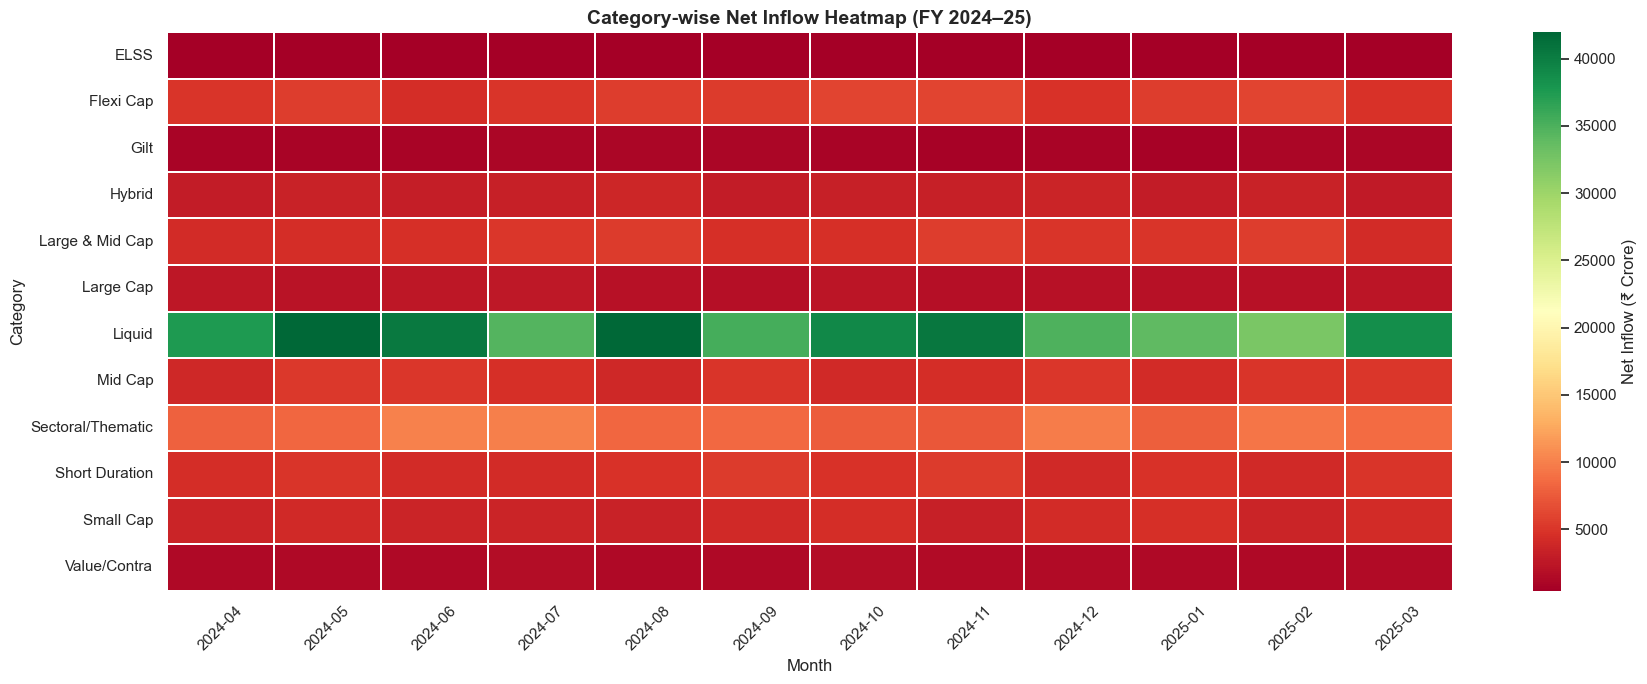

In [6]:
cat['month_str'] = cat['month'].dt.strftime('%Y-%m')
pivot = cat.pivot_table(index='category', columns='month_str', values='net_inflow_crore', aggfunc='sum')

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(pivot, cmap='RdYlGn', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Net Inflow (₹ Crore)'})
ax.set_title('Category-wise Net Inflow Heatmap (FY 2024–25)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Category')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart04_category_heatmap.png', dpi=150)
plt.show()

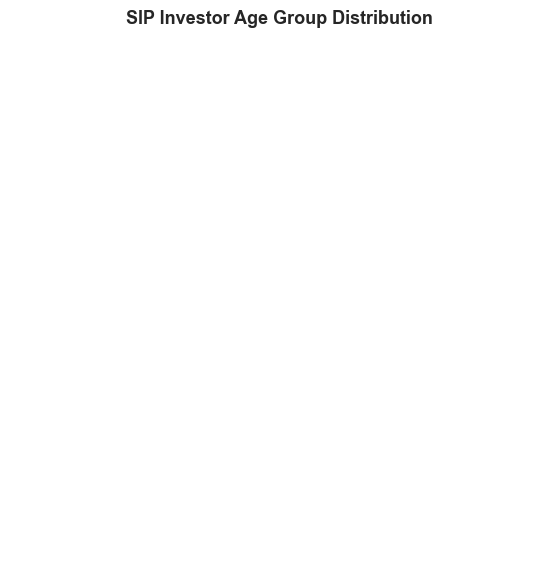

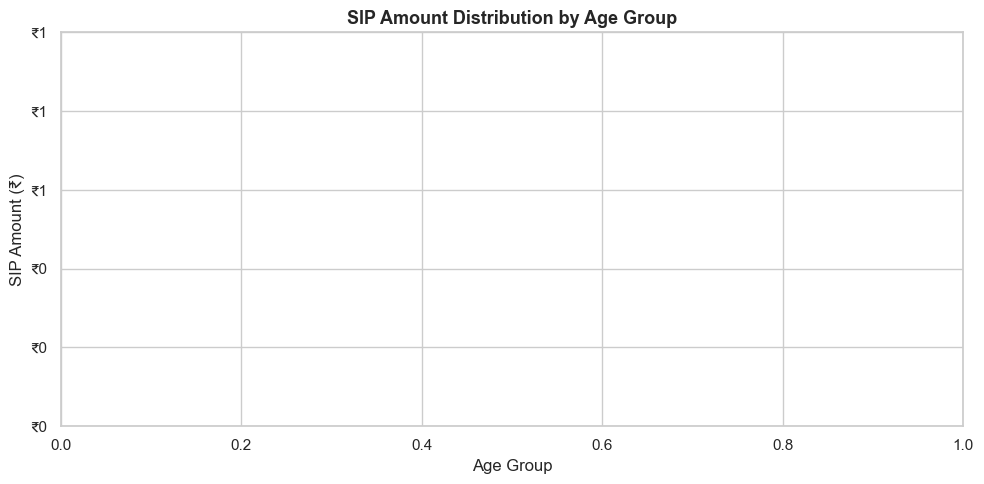

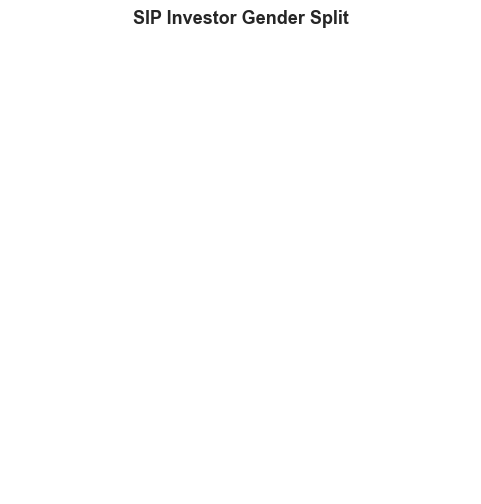

In [7]:
sip_txn = txn[txn['transaction_type'] == 'SIP']

# Chart 5a — Age group pie
age_counts = sip_txn['age_group'].value_counts().reset_index()
age_counts.columns = ['age_group', 'count']
age_order = ['18-25','26-35','36-45','46-55','56+']
age_counts['age_group'] = pd.Categorical(age_counts['age_group'], categories=age_order, ordered=True)
age_counts = age_counts.sort_values('age_group')

fig1, ax1 = plt.subplots(figsize=(7, 7))
ax1.pie(age_counts['count'], labels=age_counts['age_group'],
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('pastel', len(age_counts)))
ax1.set_title('SIP Investor Age Group Distribution', fontsize=13, fontweight='bold')
plt.savefig(CHART_DIR / 'chart05a_age_pie.png', dpi=150)
plt.show()

# Chart 5b — Box plot SIP amount by age group
fig2, ax2 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sip_txn, x='age_group', y='amount_inr',
            order=age_order, palette='muted', ax=ax2)
ax2.set_title('SIP Amount Distribution by Age Group', fontsize=13, fontweight='bold')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('SIP Amount (₹)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart05b_age_boxplot.png', dpi=150)
plt.show()

# Chart 5c — Gender split
gender_counts = sip_txn['gender'].value_counts()
fig3, ax3 = plt.subplots(figsize=(6, 6))
ax3.pie(gender_counts, labels=gender_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=['#AEC6CF','#FFB347'])
ax3.set_title('SIP Investor Gender Split', fontsize=13, fontweight='bold')
plt.savefig(CHART_DIR / 'chart05c_gender_pie.png', dpi=150)
plt.show()

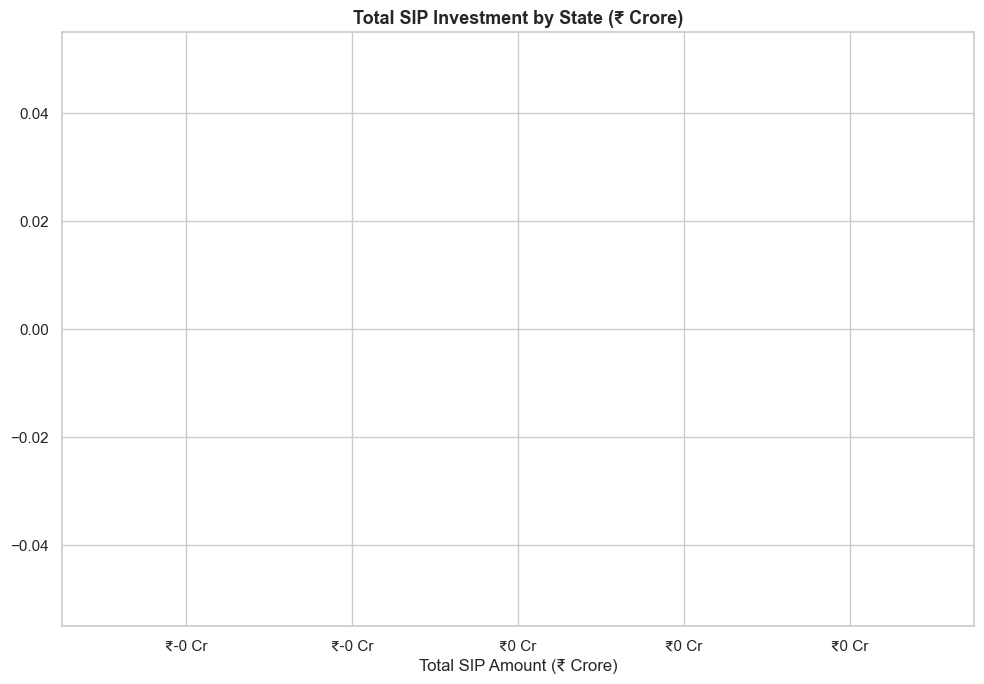

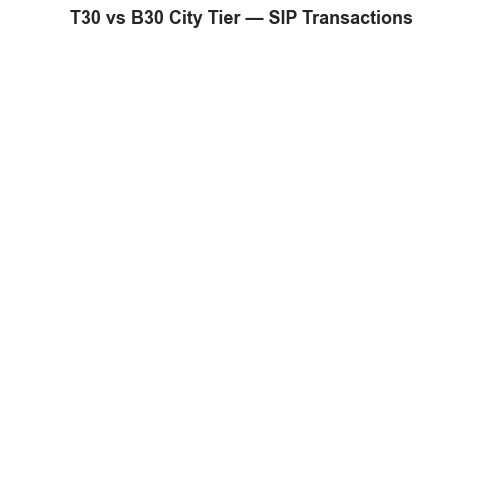

In [8]:
# Chart 6a — SIP by state
state_sip = (sip_txn.groupby('state')['amount_inr']
             .sum().sort_values(ascending=True).reset_index())

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(state_sip['state'], state_sip['amount_inr'] / 1e7,
               color=sns.color_palette('Blues_d', len(state_sip)))
ax.set_title('Total SIP Investment by State (₹ Crore)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total SIP Amount (₹ Crore)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f} Cr'))
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart06a_state_bar.png', dpi=150)
plt.show()

# Chart 6b — T30 vs B30
tier_counts = sip_txn['city_tier'].value_counts()
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.pie(tier_counts, labels=tier_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=['#4C72B0','#DD8452'])
ax2.set_title('T30 vs B30 City Tier — SIP Transactions', fontsize=13, fontweight='bold')
plt.savefig(CHART_DIR / 'chart06b_tier_pie.png', dpi=150)
plt.show()

Resorting to unclean kill browser.


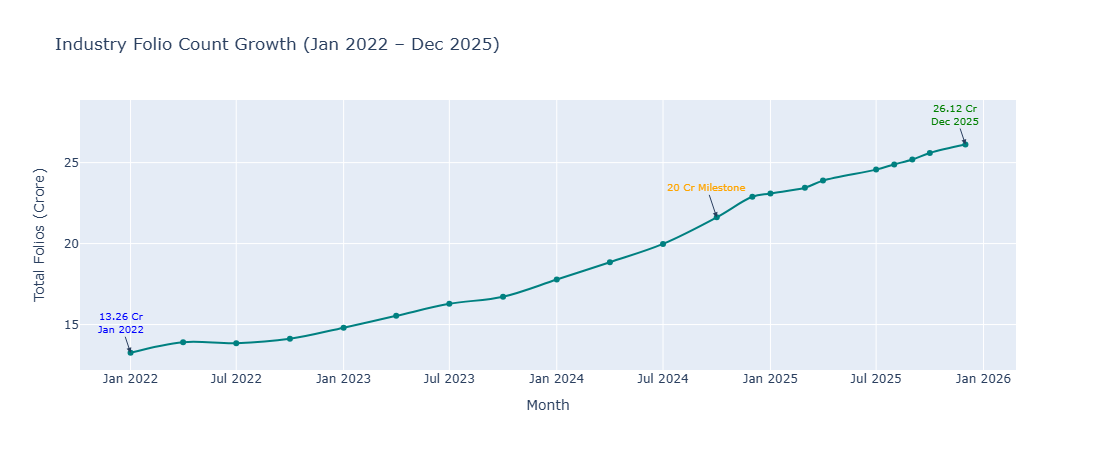

In [9]:
fig = px.line(
    folio, x='month', y='total_folios_crore',
    title='Industry Folio Count Growth (Jan 2022 – Dec 2025)',
    labels={'total_folios_crore': 'Total Folios (Crore)', 'month': 'Month'},
    markers=True, line_shape='spline'
)
# Mark start
fig.add_annotation(x=folio['month'].iloc[0],  y=folio['total_folios_crore'].iloc[0],
                   text='13.26 Cr<br>Jan 2022', showarrow=True,
                   arrowhead=2, font=dict(color='blue', size=10))
# Mark end
fig.add_annotation(x=folio['month'].iloc[-1], y=folio['total_folios_crore'].iloc[-1],
                   text='26.12 Cr<br>Dec 2025', showarrow=True,
                   arrowhead=2, font=dict(color='green', size=10))
# Mark 20 Cr milestone
milestone = folio[folio['total_folios_crore'] >= 20].iloc[0]
fig.add_annotation(x=milestone['month'], y=milestone['total_folios_crore'],
                   text='20 Cr Milestone', showarrow=True,
                   arrowhead=2, font=dict(color='orange', size=10))
fig.update_traces(line_color='teal', line_width=2)
fig.update_layout(height=450)
try:
    fig.write_image(str(CHART_DIR / 'chart07_folio_growth.png'))
except Exception:
    pass  # kaleido not installed; skipping PNG export
fig.show()

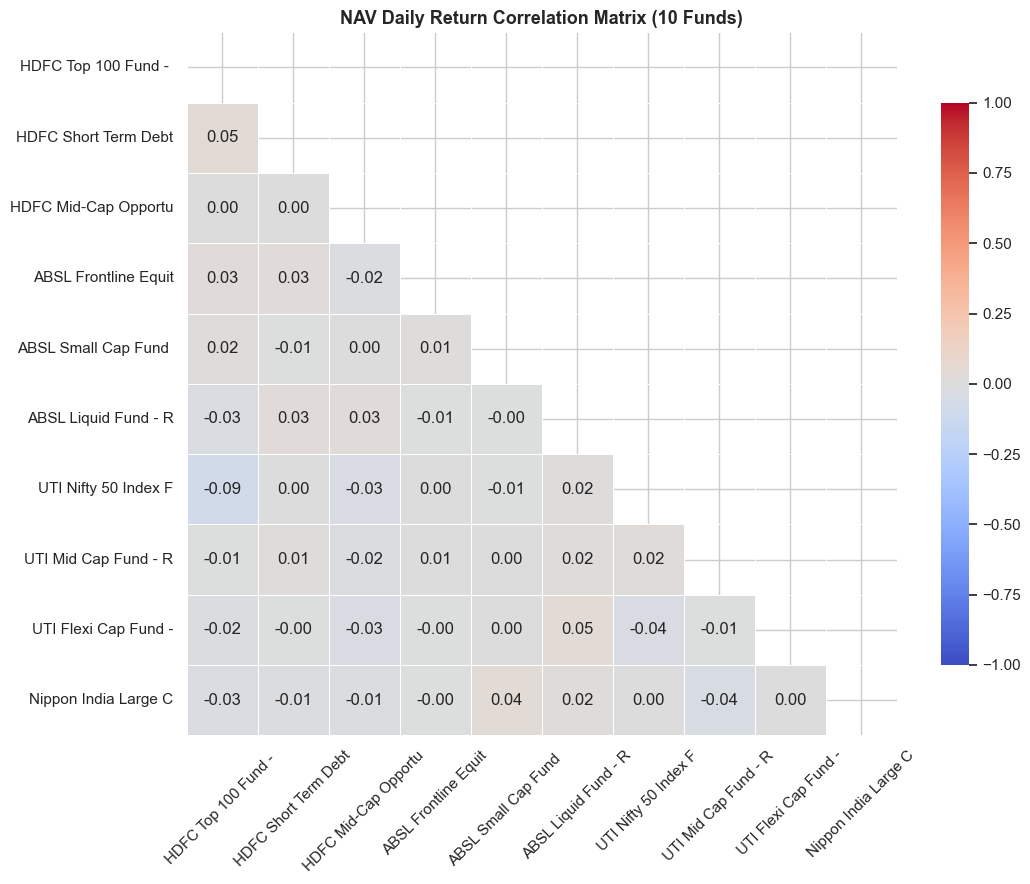

In [10]:
# Select 10 funds
ten_codes = nav_named['amfi_code'].unique()[:10]
ten_names = nav_named[nav_named['amfi_code'].isin(ten_codes)][['amfi_code','scheme_name']].drop_duplicates()
code_to_name = dict(zip(ten_names['amfi_code'], ten_names['scheme_name'].str[:20]))

# Pivot: rows = date, columns = fund, values = daily_return_pct
nav_pivot = (nav[nav['amfi_code'].isin(ten_codes)]
             .pivot_table(index='date', columns='amfi_code', values='daily_return_pct'))
nav_pivot.columns = [code_to_name.get(c, str(c)) for c in nav_pivot.columns]

corr = nav_pivot.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('NAV Daily Return Correlation Matrix (10 Funds)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart08_correlation_matrix.png', dpi=150)
plt.show()

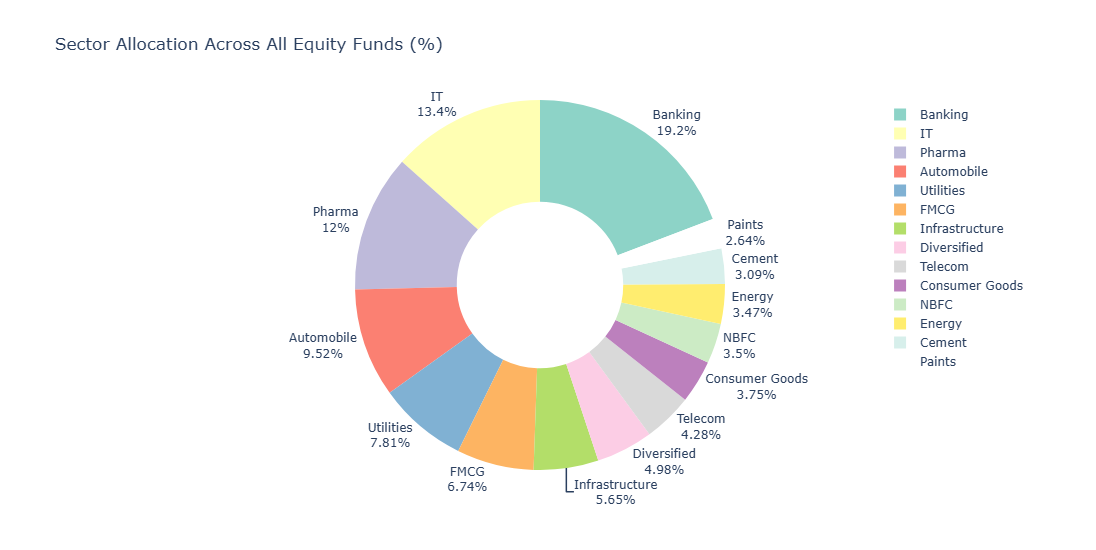

In [11]:
sector_wt = port.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).reset_index()
sector_wt['weight_pct_norm'] = sector_wt['weight_pct'] / sector_wt['weight_pct'].sum() * 100

fig = px.pie(
    sector_wt, names='sector', values='weight_pct_norm',
    hole=0.45,
    title='Sector Allocation Across All Equity Funds (%)',
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(height=550, showlegend=True)
try:
    fig.write_image(str(CHART_DIR / 'chart09_sector_donut.png'))
except Exception:
    pass  # kaleido not installed; skipping PNG export
fig.show()

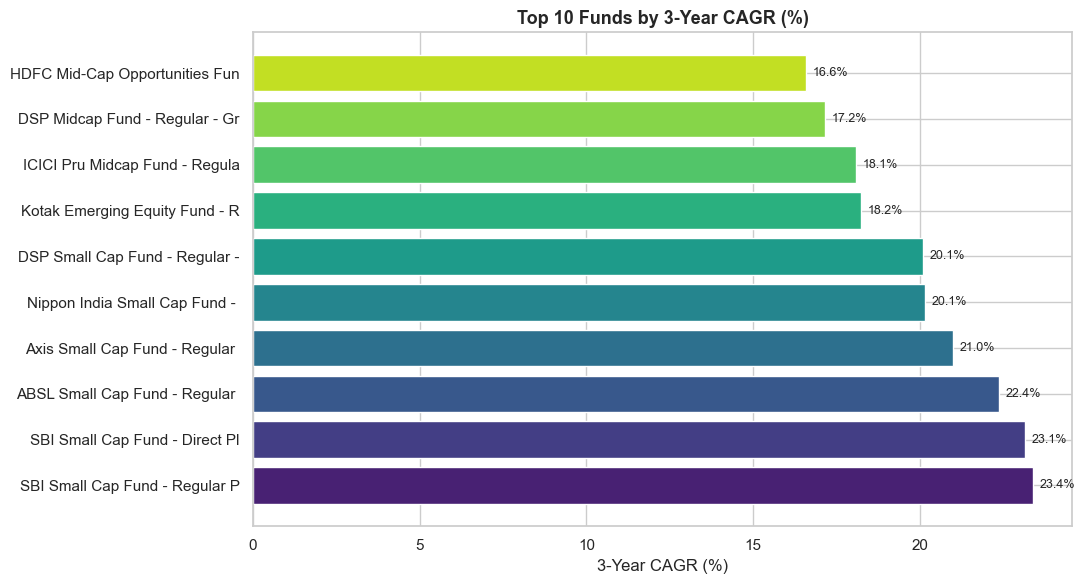

In [12]:
top_return = perf.nlargest(10, 'return_3yr_pct')[['scheme_name','return_3yr_pct','sharpe_ratio']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_return['scheme_name'].str[:30], top_return['return_3yr_pct'],
               color=sns.color_palette('viridis', 10))
ax.set_title('Top 10 Funds by 3-Year CAGR (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('3-Year CAGR (%)')
for bar, val in zip(bars, top_return['return_3yr_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart10_top_returns.png', dpi=150)
plt.show()

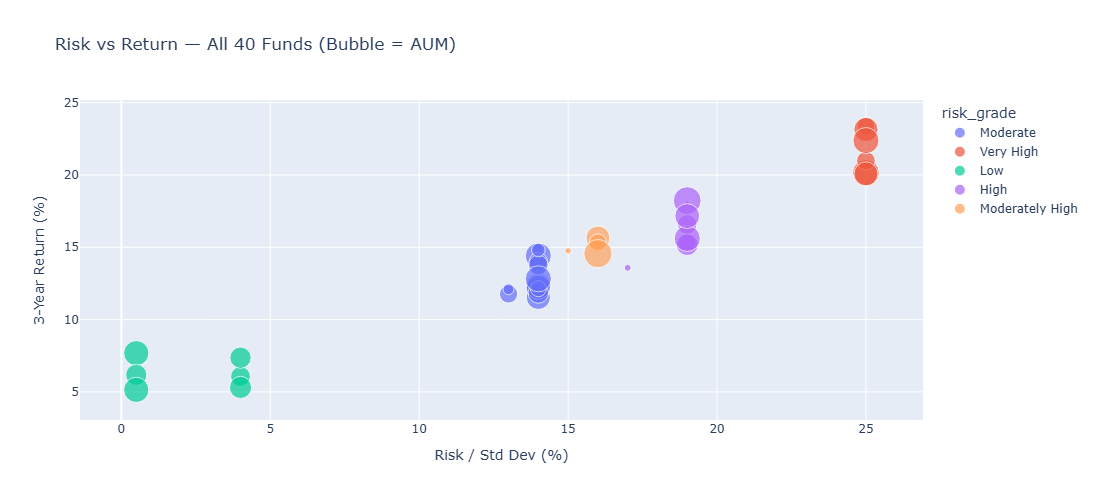

In [13]:
fig = px.scatter(
    perf, x='std_dev_ann_pct', y='return_3yr_pct',
    size='aum_crore', color='risk_grade', hover_name='scheme_name',
    title='Risk vs Return — All 40 Funds (Bubble = AUM)',
    labels={'std_dev_ann_pct': 'Risk / Std Dev (%)', 'return_3yr_pct': '3-Year Return (%)'}
)
fig.update_layout(height=500)
try:
    fig.write_image(str(CHART_DIR / 'chart11_risk_return.png'))
except Exception:
    pass  # kaleido not installed; skipping PNG export
fig.show()

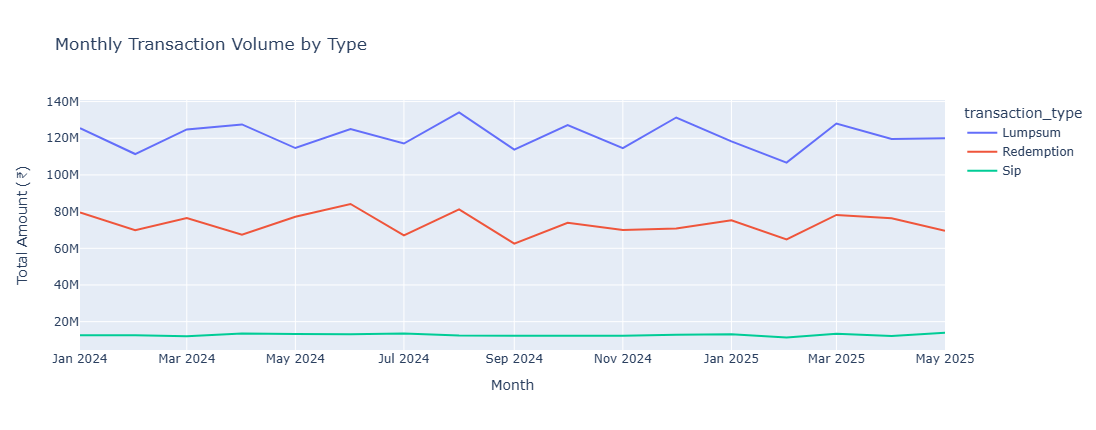

In [14]:
txn['month'] = txn['transaction_date'].dt.to_period('M').dt.to_timestamp()
txn_vol = txn.groupby(['month','transaction_type'])['amount_inr'].sum().reset_index()

fig = px.line(
    txn_vol, x='month', y='amount_inr', color='transaction_type',
    title='Monthly Transaction Volume by Type',
    labels={'amount_inr': 'Total Amount (₹)', 'month': 'Month'}
)
fig.update_layout(height=430)
try:
    fig.write_image(str(CHART_DIR / 'chart12_txn_volume.png'))
except Exception:
    pass  # kaleido not installed; skipping PNG export
fig.show()

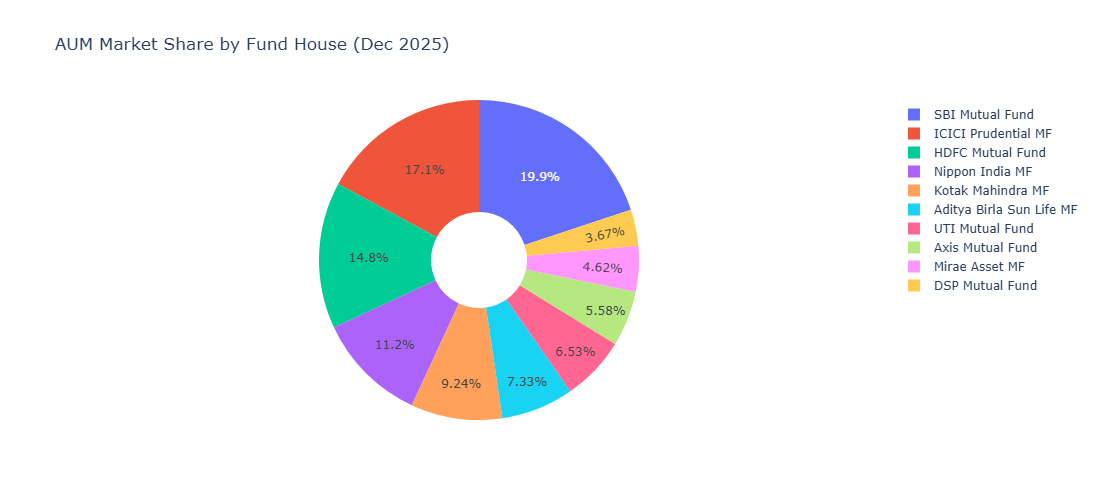

In [15]:
latest_aum = aum[aum['date'] == aum['date'].max()]

fig = px.pie(
    latest_aum, names='fund_house', values='aum_lakh_crore',
    title=f'AUM Market Share by Fund House ({aum["date"].max().strftime("%b %Y")})',
    hole=0.3, color_discrete_sequence=px.colors.qualitative.Plotly
)
fig.update_layout(height=500)
try:
    fig.write_image(str(CHART_DIR / 'chart13_aum_share.png'))
except Exception:
    pass  # kaleido not installed; skipping PNG export
fig.show()

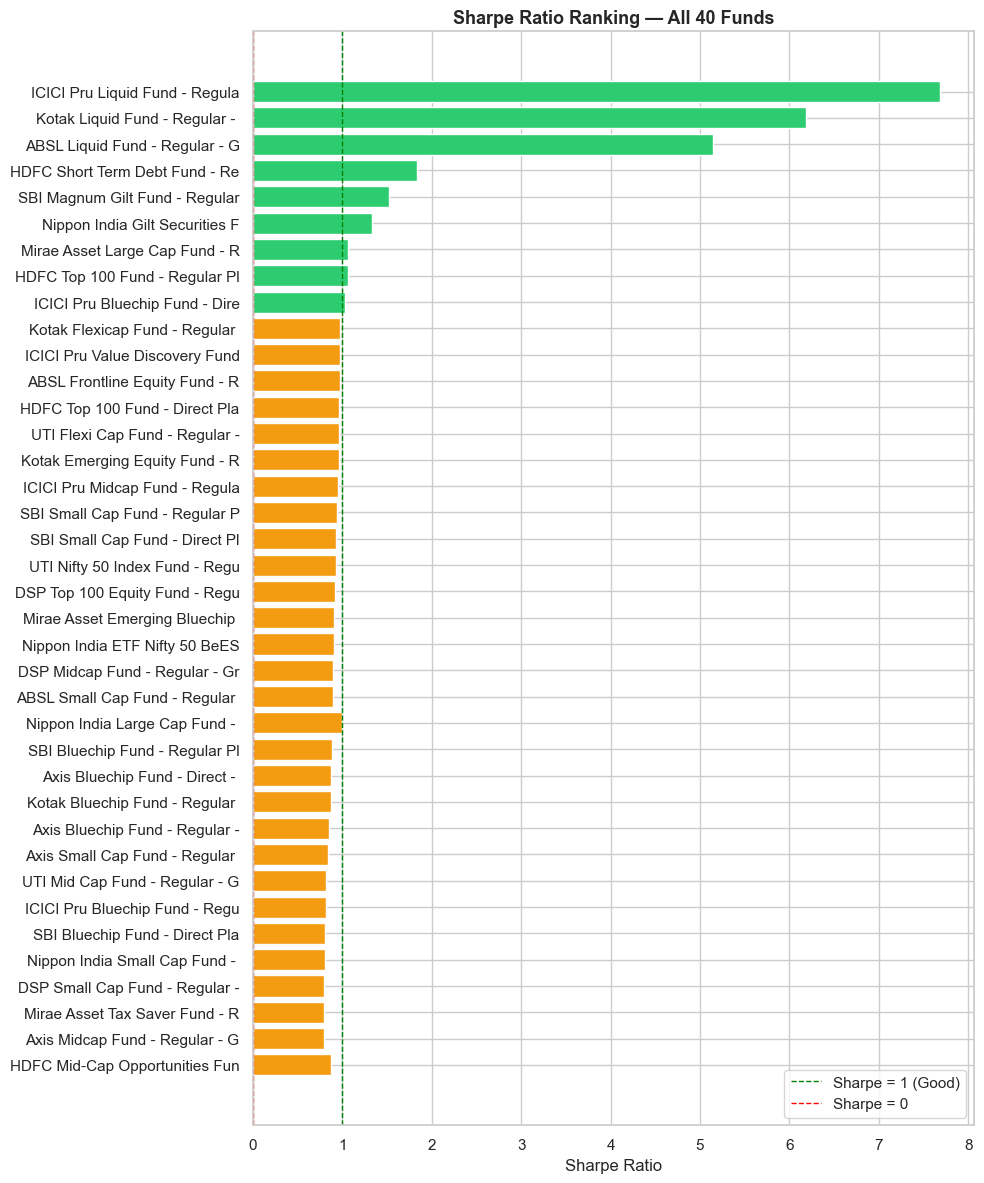

In [16]:
sharpe_sorted = perf.sort_values('sharpe_ratio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#2ecc71' if x > 1 else '#e74c3c' if x < 0 else '#f39c12'
          for x in sharpe_sorted['sharpe_ratio']]
ax.barh(sharpe_sorted['scheme_name'].str[:30], sharpe_sorted['sharpe_ratio'], color=colors)
ax.axvline(x=1, color='green', linestyle='--', linewidth=1, label='Sharpe = 1 (Good)')
ax.axvline(x=0, color='red',   linestyle='--', linewidth=1, label='Sharpe = 0')
ax.set_title('Sharpe Ratio Ranking — All 40 Funds', fontsize=13, fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart14_sharpe_ranking.png', dpi=150)
plt.show()

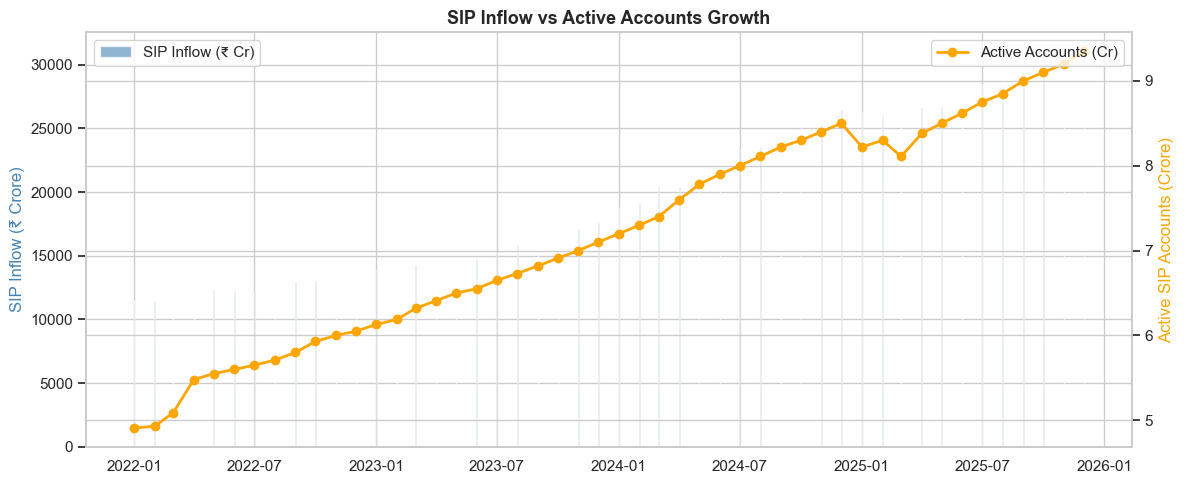

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(sip['month'], sip['sip_inflow_crore'], color='steelblue', alpha=0.6, label='SIP Inflow (₹ Cr)')
ax2.plot(sip['month'], sip['active_sip_accounts_crore'], color='orange', linewidth=2, marker='o', label='Active Accounts (Cr)')

ax1.set_title('SIP Inflow vs Active Accounts Growth', fontsize=13, fontweight='bold')
ax1.set_ylabel('SIP Inflow (₹ Crore)', color='steelblue')
ax2.set_ylabel('Active SIP Accounts (Crore)', color='orange')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(CHART_DIR / 'chart15_sip_accounts.png', dpi=150)
plt.show()